# Does the yen really rally when stocks crash? 🇯🇵
### The "free crash hedge" legend, tested on thirty years of tape — in plain English

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![2022 failure?: Confirmed](https://img.shields.io/badge/2022_failure%3F-Confirmed-8b949e?style=flat-square)

Every trading floor knows the story. For decades, Japan had the lowest interest rates on Earth, so the world **borrowed yen** for almost nothing and bought anything that paid more — the famous **carry trade**. When markets panic, those trades get unwound in a hurry: everyone has to **buy back the yen they borrowed**, all at once. Result, says the legend: *when stocks crash, the yen rallies* — a crash hedge you get **for free**.

It has a highlight reel: 2008, the August-2015 flash crash, the COVID panic, the August-2024 carry unwind. It also has one very loud counter-example: **2022**, when US stocks fell 25% and the yen... fell 21% at the same time.

So which is it — free insurance, or a story that quietly bills you? *(Our sibling study [69-safe-haven](../../69-safe-haven/README.md) asks the same question of **gold** — different asset, different mechanism, and, it turns out, a different way of disappointing you.)*

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the regime splits and the carry math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ Every chart is drawn by the code beside it from the cached tape (yfinance `JPY=X` + `SPY`, 1996–2026). House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from yen_safe_haven import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    TAPE = data.load_real()                  # as-of'd daily tape (usdjpy, spy, irx, tnx)
    RETS = st.to_returns(TAPE)
    M = st.monthly_returns(TAPE)
else:
    TAPE = RETS = M = None
print("real tape cached:", HAVE_REAL,
      "| daily returns:", (0 if RETS is None else len(RETS)),
      "| months:", (0 if M is None else len(M)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1996-10-30', 'end': '2026-06-30', 'years': 29.4, 'n_days': 7418, 'n_months': 356, 'fingerprint': '6d34d723338d', 'as_of': '2026-06-30', 'beta_dn': -0.113, 't_dn': -4.62, 'beta_up': -0.046, 't_up': -1.94, 'beta_all': -0.08, 't_all': -4.45, 'r2': 0.02, 'nw_lags': 10, 'q_means': [12.17, -1.35, -3.06, -4.2, -6.64], 'spy_q1_bps': -157.1, 't_q1_q5': 5.81, 't_q1_mid': 5.81, 'dn_bps': -8.51, 'up_bps': -17.16, 'n_dn': 128, 'n_up': 228, 't_month': 0.26, 'dec_n': 35, 'dec_spy': -7.93, 'dec_jpy': 0.39, 'dec_hit': 57, 'drop_all_ev_t': -4.27, 'drop_all_ev_welch': 3.97, 'drop_all_ev_n': 5924, 'drop100_t': -3.02, 'drop100_welch': 4.68, 'boot_welch_mean': 5.72, 'boot_frac_gt2': 100, 'sub': [('1996-2010', 3529, -0.179, -6.18, 24.04, 5.57), ('2011-2026', 3889, -0.022, -0.89, -0.83, 1.03), ('2016-2026', 2633, -0.011, -0.38, -0.92, 0.16)], 'events': [('GFC deleveraging (Lehman -> year-end)', '2008-09-12', '2008-12-31', -27.43, 19.07, True), ('Aug-2015 (CNY deval + flash crash)', '2015-08-10', '2015-08-25', -11.07, 4.56, True), ('COVID risk-off leg (peak -> 03-09)', '2020-02-19', '2020-03-09', -18.95, 5.75, True), ('COVID dollar scramble (03-09 -> trough)', '2020-03-09', '2020-03-23', -18.22, -5.91, False), ('2022 bear market (top -> trough)', '2022-01-03', '2022-10-12', -24.5, -21.07, False), ('Aug-2024 carry unwind (BOJ hike -> crash)', '2024-07-31', '2024-08-05', -6.07, 4.87, True)], 'hi_beta_dn': -0.097, 'hi_t_dn': -3.83, 'hi_n': 3310, 'hi_share': 45, 'lo_beta_dn': -0.123, 'lo_t_dn': -3.59, 'lo_n': 4108, 'fell_bps': 112.53, 'rose_bps': -150.06, 'n_fell': 69, 'n_rose': 59, 't_gap': 5.14, 'spot_ann': -2.2, 'excess_ann': -4.34, 'net_ann': -4.74, 'avg_bill': 2.21, 'expense_bps': 40, 'spy_2022': -24.5, 'jpy_2022': -21.07, 'ratio_2022': 86, 'syn': [(0.0, 0.015, 1.32, -3.22, -1.59), (0.3, -0.284, -25.91, 45.74, 20.75)]}


real tape cached: True | daily returns: 7418 | months: 356


## The answer first

| Question | Answer |
|---|---|
| Does the yen jump on scary days? | **It used to.** Over the full 30 years, on the worst 20% of S&P days it gained about **+12 bps a day** while everything else burned — a genuine signal, not luck (it survives dropping every crash and a bootstrap). But it has **faded**: almost all of it is 1996–2010, and since 2011 the daily jump is essentially **gone**. |
| Does it hedge whole bear markets? | **No.** Over full *months*, down-months and up-months look the same for the yen. In the 35 worst S&P months it rose only **57%** of the time. |
| Is the insurance free? | **Absolutely not.** Holding yen cost about **4.7% a year, for thirty years** — you pay the carry the legend's heroes were *earning*. |
| And 2022? | The hedge **failed exactly when needed** — and for a knowable reason: that crash was caused by *rising rates*, which makes the yen weaker, not stronger. |

## One picture of the whole legend

Yen strength (the inverse of the USD/JPY rate — up = strong yen) against the S&P 500, with the famous panic episodes shaded. You can *see* the legend: yen spikes at 2008, 2015, early-2020, Aug-2024... and the huge 2022–2024 slide where it fell *with* stocks.

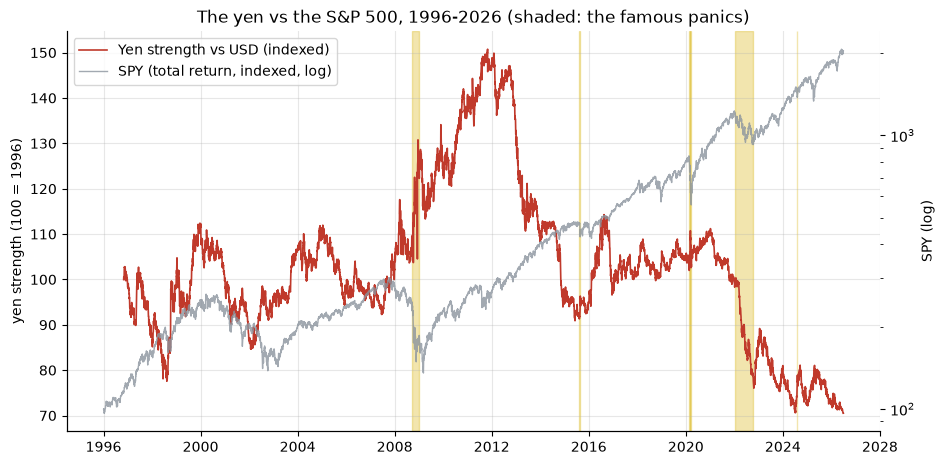

In [2]:
if HAVE_REAL:
    fig, ax = plt.subplots(figsize=(10.5, 5.2))
    yen = 100.0 / TAPE['usdjpy'].dropna()          # yen strength, up = strong
    yen = 100 * yen / yen.iloc[0]
    spy = TAPE['spy'].dropna()
    spy = 100 * spy / spy.iloc[0]
    ax.plot(yen.index, yen.values, color=RED, lw=1.2, label='Yen strength vs USD (indexed)')
    ax2 = ax.twinx()
    ax2.plot(spy.index, spy.values, color=GREY, lw=1.0, alpha=.8, label='SPY (total return, indexed, log)')
    ax2.set_yscale('log'); ax2.grid(False)
    for lab, s, e in data.EVENTS:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color=AMBER, alpha=.35)
    ax.set_title('The yen vs the S&P 500, 1996-2026 (shaded: the famous panics)')
    ax.set_ylabel('yen strength (100 = 1996)'); ax2.set_ylabel('SPY (log)')
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='upper left')
    plt.show()
else:
    print('cache missing - see docs/results.md for the frozen numbers')

## Scary days: the legend is true

Sort every trading day since 1996 into five buckets by how the S&P did. On the **worst** bucket (average S&P day ≈ −1.6%), the yen *gained*. On every other bucket it drifted down. That staircase is exactly what a crash hedge should look like — and the quants' notebook confirms it's far too clean to be luck.

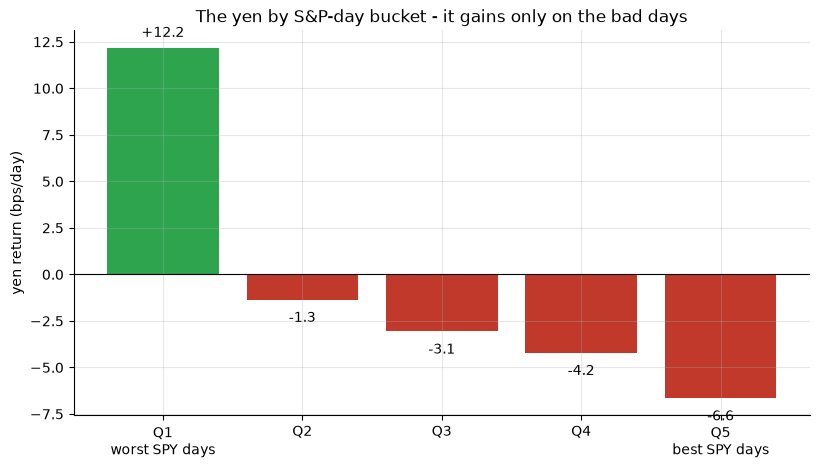

Q1 mean +12.17 bps/day on days when SPY averaged -157 bps


In [3]:
if HAVE_REAL:
    Q = st.quintile_ladder(RETS)
    means = Q['means_bps']
else:
    means = R['q_means']
fig, ax = plt.subplots()
labels = ['Q1\nworst SPY days', 'Q2', 'Q3', 'Q4', 'Q5\nbest SPY days']
colors = [GREEN if v > 0 else RED for v in means]
ax.bar(labels, means, color=colors)
ax.axhline(0, color='k', lw=.8)
ax.set_ylabel('yen return (bps/day)')
ax.set_title('The yen by S&P-day bucket - it gains only on the bad days')
for i, v in enumerate(means):
    ax.text(i, v + (0.6 if v > 0 else -1.2), f'{v:+.1f}', ha='center')
plt.show()
print(f"Q1 mean {means[0]:+.2f} bps/day on days when SPY averaged {R['spy_q1_bps']:+.0f} bps")

## The highlight reel — and the two nights the hero didn't show

Six famous panics, side by side. Four times the yen delivered handsomely. Twice it failed — the March-2020 **dollar scramble** (when the whole world needed dollars *right now* and sold everything else, even yen), and the **2022 bear market**, the longest, slowest crash of the sample... where the "hedge" lost almost as much as the stocks it was supposed to protect.

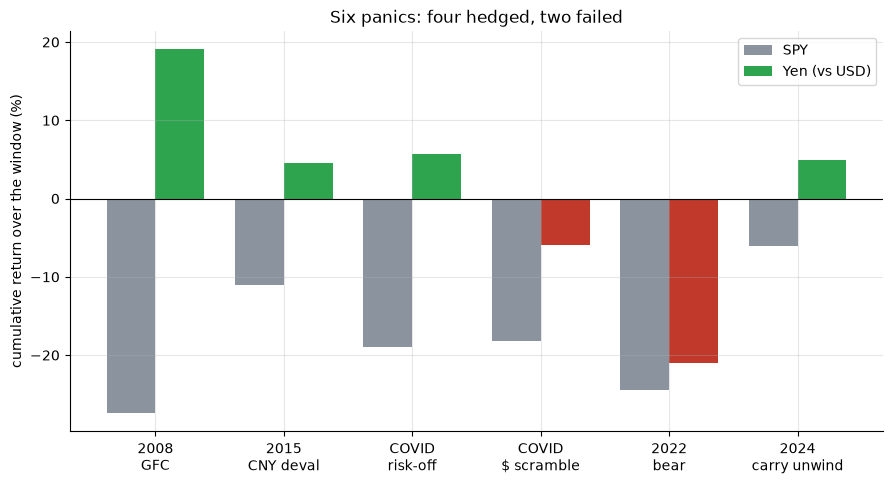

In [4]:
if HAVE_REAL:
    EV = st.event_table(TAPE)
    rows = [(e['label'], e['spy_pct'], e['jpy_pct']) for e in EV]
else:
    rows = [(lab, s_, j_) for lab, _a, _b, s_, j_, _h in R['events']]
fig, ax = plt.subplots(figsize=(10.5, 5.2))
x = np.arange(len(rows)); w = 0.38
ax.bar(x - w/2, [r[1] for r in rows], w, color=GREY, label='SPY')
ax.bar(x + w/2, [r[2] for r in rows], w,
       color=[GREEN if r[2] > 0 else RED for r in rows], label='Yen (vs USD)')
ax.axhline(0, color='k', lw=.8)
ax.set_xticks(x)
ax.set_xticklabels(['2008\nGFC', '2015\nCNY deval', 'COVID\nrisk-off', 'COVID\n$ scramble',
                    '2022\nbear', '2024\ncarry unwind'])
ax.set_ylabel('cumulative return over the window (%)')
ax.set_title('Six panics: four hedged, two failed')
ax.legend()
plt.show()

## The bill nobody mentions

To own this hedge you hold yen instead of dollars. Dollars earned interest (about **2.2%/yr** on average since 1996); yen earned roughly zero — *that gap is the same carry the legend's traders were harvesting, and as the hedge-owner you're on the **paying** side of it.* Add the yen's own slow slide and an ETF fee, and "free insurance" cost about **4.7% a year, every year, for 29 years**. Here is what a dollar kept in the yen sleeve (after the interest you gave up) looked like:

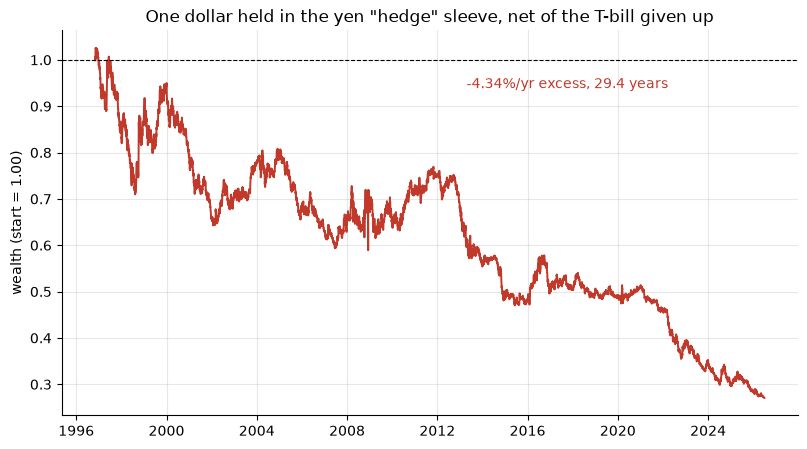

final wealth of $1: $0.27


In [5]:
if HAVE_REAL:
    bill = RETS['irx'].values / 100.0 / 252.0
    ex = RETS['jpy'].values - bill
    wealth = pd.Series(np.exp(np.cumsum(np.log1p(ex))), index=RETS.index)
    fig, ax = plt.subplots()
    ax.plot(wealth.index, wealth.values, color=RED, lw=1.4)
    ax.axhline(1.0, color='k', lw=.8, ls='--')
    ax.set_title('One dollar held in the yen "hedge" sleeve, net of the T-bill given up')
    ax.set_ylabel('wealth (start = 1.00)')
    ax.annotate(f"{R['excess_ann']:+.2f}%/yr excess, {R['years']:.1f} years",
                xy=(0.55, 0.85), xycoords='axes fraction', color=RED)
    plt.show()
    print(f'final wealth of $1: ${wealth.iloc[-1]:.2f}')
else:
    print(f"excess {R['excess_ann']:+.2f}%/yr, net {R['net_ann']:+.2f}%/yr - see docs/results.md")

## Why 2022 wasn't bad luck

Split all the S&P's *down months* by what interest rates did at the same time:

- Stocks down because of a **growth scare** (rates falling): the yen made **about +1.1% a month**. That's 2008, 2020's first leg, 2024.
- Stocks down because of a **rate shock** (rates rising): the yen **lost about -1.5% a month**. That's 2022, in one line.

When a crash is caused by *rising US rates*, borrowing yen to hold dollars gets **more** attractive every week — so the carry trade grows *during* the selloff instead of unwinding. The yen doesn't hedge crashes. It hedges **fear about growth**. 2022 was fear about rates.

## The verdict

| Question | Verdict |
|---|---|
| Yen jumps on crash days? | **REAL** — the cleanest daily safe-haven signature on this desk |
| An ownable crash hedge? | **MIRAGE** — ~4.7%/yr of negative carry, no monthly hedge value, and it skips rate-driven bears |
| "2022: failed exactly when needed"? | **CONFIRMED** — yen −21% while SPY −25%, and the mechanism says that was the *expected* outcome |

> 🔬 **For the quants:** the HAC *t*-stats, both regime splits, the carry accounting and the planted-hedge synthetic control live in [02_for_the_quants.ipynb](02_for_the_quants.ipynb).

*Fingerprinted headline run: [docs/results.md](../docs/results.md) (as-of 2026-06-30, fingerprint `6d34d723338d`). Not investment advice.*